In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
rubisco_dms = pd.read_csv("/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/raw_data/RBL2_RHORT_Prywes_2025/41586_2024_8455_MOESM4_ESM.csv", index_col=0).set_index("mutant")

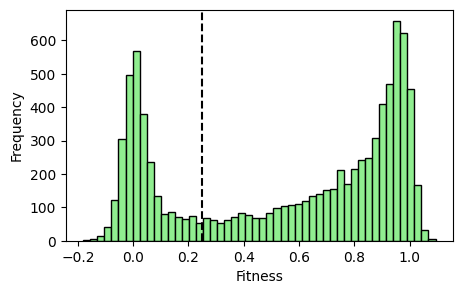

In [36]:
plt.figure(figsize=(5,3))
plt.hist(rubisco_dms.Fitness, bins=50, color='lightgreen', ec='k')
plt.xlabel('Fitness')
plt.ylabel('Frequency')

plt.axvline(0.25, c='k', ls='--')

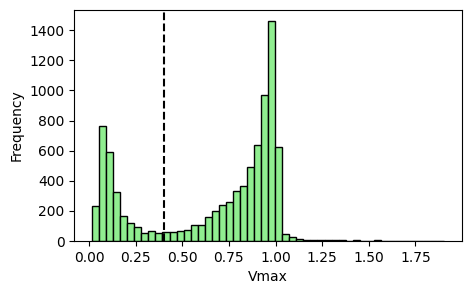

In [37]:
plt.figure(figsize=(5,3))
plt.hist(rubisco_dms.Vmax_median, bins=50, color='lightgreen', ec='k')
plt.xlabel('Vmax')
plt.ylabel('Frequency')

plt.axvline(0.4, c='k', ls='--')

Text(0, 0.5, 'Frequency')

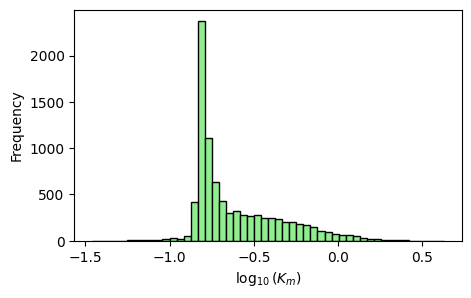

In [38]:
plt.figure(figsize=(5,3))
plt.hist(np.log10(rubisco_dms.Km_median), bins=50, color='lightgreen', ec='k')
plt.xlabel('$\log_{10}(K_m)$')
plt.ylabel('Frequency')

#plt.axvline(0.4, c='k', ls='--')

Text(0, 0.5, 'Vmax (median estimate)')

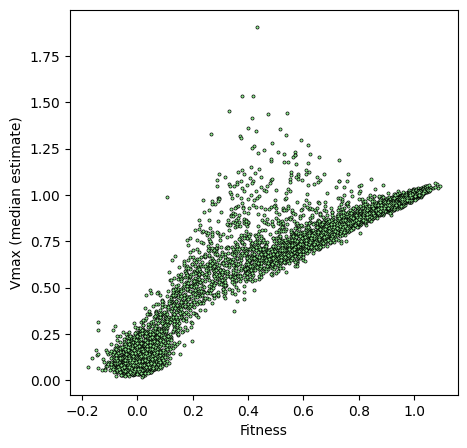

In [20]:
plt.figure(figsize=(5,5))
plt.scatter(rubisco_dms.Fitness, rubisco_dms.Vmax_median, s=5, ec='k',c='lightgreen', lw=0.5)
plt.xlabel("Fitness")
plt.ylabel("Vmax (median estimate)")

In [32]:
rubisco_seq = "MDQSSRYVNLALKEEDLIAGGEHVLCAYIMKPKAGYGYVATAAHFAAESSTGTNVEVCTTDDFTRGVDALVYEVDEARELTKIAYPVALFDRNITDGKAMIASFLTLTMGNNQGMGDVEYAKMHDFYVPEAYRALFDGPSVNISALWKVLGRPEVDGGLVVGTIIKPKLGLRPKPFAEACHAFWLGGDFIKNDEPQGNQPFAPLRDTIALVADAMRRAQDETGEAKLFSANITADDPFEIIARGEYVLETFGENASHVALLVDGYVAGAAAITTARRRFPDNFLHYHRAGHGAVTSPQSKRGYTAFVHCKMARLQGASGIHTGTMGFGKMEGESSDRAIAYMLTQDEAQGPFYRQSWGGMKACTPIISGGMNALRMPGFFENLGNANVILTAGGGAFGHIDGPVAGARSLRQAWQAWRDGVPVLDYAREHKELARAFESFPGDADQIYPGWRKALGVEDTRSALPA"

def get_variant(reference, mutations, start_index=1):
    variant = reference.copy()
    for mut in mutations:
        pos = int(mut[1:-1])-start_index
        variant[pos] = mut[-1]
    return variant

mutants = pd.Series([''.join(get_variant(np.array(list(rubisco_seq)), [n])) for n,row in rubisco_dms.iterrows()], index=rubisco_dms.index)

aa_sequence = pd.concat([rubisco_dms.iloc[:, 0], 
          mutants], axis=1).rename(columns={0:"aa_sequence"})

In [34]:
#rubisco_dms.set_index("mutant", inplace=True)

In [35]:
pd.concat([aa_sequence, rubisco_dms[['Km_median', 'Km_qbcov']]], axis=1).to_csv("/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/RBL2_RHORT_Prywes_2025/RBL2_RHORT_Prywes_2025_Km.csv")
pd.concat([aa_sequence, rubisco_dms[['Vmax_median', 'Vmax_qbcov']]], axis=1).to_csv("/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/RBL2_RHORT_Prywes_2025/RBL2_RHORT_Prywes_2025_Vmax.csv")